<a href="https://colab.research.google.com/github/LeoFairley123/EMSC2010-WK4.2/blob/main/EMSC2010_W4_P2_NB1_u7488277.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010_W4_P2_NB1
---

*   Class: EMSC2010
*   Week: 4
*   Session: Practical 2

---

From GitHub, you can open this notebook in Google Colab using the 'Open in Colab' button. Then:

1. Change the notebook name to include your U-number (e.g EMSC2010_W4_P2_NB1_uXXXXXXX.ipynb)
2. Save to Google Drive (*File* >>> *Save a copy in Drive*)

Any edits you make will be saved in your Google Drive. To save your editted version to GitHub

3. Commit to GitHub (*File* >>> *Save a copy in GitHub*)
4. Select the repository for your commit (same as your original repository)
5. Give a brief commit message (e.g. 'Commit including adjustment to labels')
6. Check your GitHub repository, a copy of your notebook should be there.

---

Because Google Drive is saving your work and the work of your collaborators automatically, you don't need to commit all minor edits to GitHub. Rather commit when you want to archive a version of your notebook because you have completed a substantial task.

## Plotting the Keeling curve
Monthly mean carbon dioxide has been measured at Mauna Loa Observatory, Hawaii, since 1958.  The carbon dioxide data on Mauna Loa constitute the longest record of direct measurements of CO$_2$ in the atmosphere.

This record is referred to as the *Keeling curve* in honour of Charles Keeling who started the monitoring program and ran it until his death in 2005.

1. Search for the Mauna Loa monthly CO$_2$ data.
2. Download the data and put it into a Excel workbook (or similar)
3. Create a new Colab notebook (you don't need a GitHub template for this).
4. "Mount" the data in your Colab notebook
5. Use pandas to read in the CO$_2$ data.
6. Use Matplotlib to plot the CO$_2$ data against time, label your axes, etc.
7. Annotate your notebook to describe your workflow, explain your code, cite data sources, etc.
8. This is NOT part of Assessment 1

In [1]:
import pandas as pd #used to read and clean data
import numpy as np #used for numerical operations
import matplotlib.pyplot as plt #used for data plotting

In [2]:
# Make sure you add the file into Colab
spreadsheet_name = '/content/monthly_in_situ_co2_mlo.csv' #read the data into a dataframe

Monthly Data acquired as in csv format from:

C. D. Keeling, S. C. Piper, R. B. Bacastow, M. Wahlen, T. P. Whorf, M. Heimann, and H. A. Meijer, Exchanges of atmospheric CO2 and 13CO2 with the terrestrial biosphere and oceans from 1978 to 2000. I. Global aspects, SIO Reference Series, No. 01-06, Scripps Institution of Oceanography, San Diego, 88 pages, 2001.

In [14]:
# Read the data, skipping the first 64 rows of metadata.
# Only read the 'year', 'month', and 'CO2_raw' columns directly.
df = pd.read_csv(
    spreadsheet_name, # Specify the path to the CSV file
    skiprows=64,      # Skip the first 64 rows, which contain metadata/headers
    usecols=[0, 1, 4], # Select columns at index 0 (year), 1 (month), and 4 (CO2_raw)
    names=['year', 'month', 'CO2_raw'], # Assign custom names to the selected columns
)
df.head() # Display the first few rows of the DataFrame to verify data loading

,year,month,CO2_raw
0,1958,1,-99.99
1,1958,2,-99.99
2,1958,3,315.71
3,1958,4,317.45
4,1958,5,317.51


In [20]:
# I asked Gemini to give me a plot template which I proceeded to change variable names
# and values to match the specific dataset. I then asked it to annotate all the lines
# of code

Certainly! Here's a summary of the contributions to the plotting cell (CH5d3O-cXn7b):

Your (the Coder's) Contributions:

You initiated the request for plotting the monthly CO2 data.
You specifically requested the filtering of CO2 values to be greater than 0, to remove invalid data points.
You asked for the inclusion of an 'average curve', which led to the 12-month rolling mean being calculated and plotted.
You requested the use of LaTeX-like syntax for 'CO$_2$$_2$' in the labels and title for proper scientific notation.
You explicitly asked for comprehensive annotations explaining each line of code within this cell.

My (the AI's) Contributions:

I provided the core code structure for generating the plot, including the setup for matplotlib.
I implemented the conversion of the CO2_raw column to a numeric type (df['CO2'] = pd.to_numeric(df['CO2_raw'])).
I wrote the code to create the date column from 'year' and 'month' and set it as the DataFrame's index, essential for time-series plotting.
I calculated and plotted the 12-month rolling mean of the CO2 concentration, using a red dashed line as requested.
I added all standard plotting elements: axis labels, a title, a grid, a legend, and plt.tight_layout() for optimal display.
I integrated the LaTeX-like syntax for 'CO$_2$$_2$' into the labels and title as you requested.
I generated the detailed line-by-line annotations (comments) present in the cell to explain the code's functionality.
(As mentioned in the context, though not directly visible in this final cell's code) I also identified and fixed a SettingWithCopyWarning during earlier iterations of data processing.

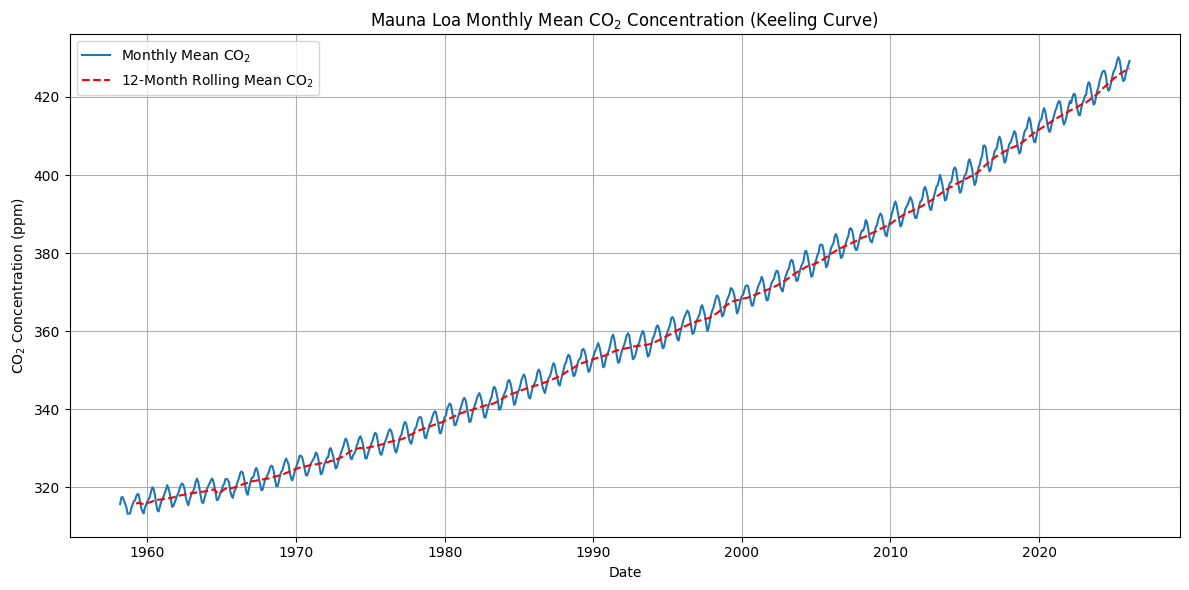

In [19]:
# Plot Keeling Curve

# Convert CO2_raw to numeric, enabling mathematical operations and plotting.
df['CO2'] = pd.to_numeric(df['CO2_raw'])

# Filter the DataFrame to remove rows where CO2 values are non-positive,
# which typically represent missing or invalid data (-99.99).
df = df[df['CO2'] > 0]

# Create a 'date' column by combining 'year' and 'month', setting the day to '01'.
# This converts the year and month into a proper datetime object.
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')
# Set the newly created 'date' column as the DataFrame's index,
# which is standard practice for time-series data.
df = df.set_index('date')

# Calculate a 12-month rolling mean of the CO2 concentration.
# This smooths out seasonal variations to show the underlying trend.
df['CO2_rolling_mean'] = df['CO2'].rolling(window=12).mean()

# Plot the data
# Create a new figure for the plot with a specified size (12x6 inches).
plt.figure(figsize=(12, 6))
# Plot the monthly mean CO2 data against the date index.
plt.plot(df.index, df['CO2'], label='Monthly Mean CO$_2$')
# Plot the 12-month rolling mean CO2 data.
# This is shown as a red, dashed line for differentiation.
plt.plot(df.index, df['CO2_rolling_mean'], color='red', linestyle='--', label='12-Month Rolling Mean CO$_2$')
# Label the x-axis as 'Date'.
plt.xlabel('Date')
# Label the y-axis as 'CO2 Concentration (ppm)', using LaTeX-like syntax for the subscript '2'.
plt.ylabel('CO$_2$ Concentration (ppm)')
# Set the title of the plot.
plt.title('Mauna Loa Monthly Mean CO$_2$ Concentration (Keeling Curve)')


# Add a grid to the plot for better readability.
plt.grid(True)
# Display the legend, which identifies the different lines in the plot.
plt.legend()
# Adjust plot parameters for a tight layout, preventing labels from overlapping.
plt.tight_layout()
# Display the plot.
plt.show()